# V9: Multi-GNN — Optuna HPO · Balanced Threshold · 5-Fold CV · Feature Importance

**Fixes over V7:**
- **Reduced Grade-1 recall**: class-weight penalty softened to `sqrt(ratio)` ≈ 1.18; per-fold G-mean threshold optimisation replaces fixed 0.5
- **AUC fix**: explicit named-column construction (no brittle positional rename); `try/except` guard for single-class folds
- **5-Fold Stratified CV**: Optuna finds best params once per model×pipeline, then `StratifiedKFold(5)` evaluates generalisation — reports mean ± std across folds
- Final model trained on full train+val, threshold = mean(fold thresholds), evaluated on held-out TCGA test + external CGGA

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import random, copy, warnings

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             precision_score, recall_score, f1_score, accuracy_score)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold

from torch_geometric.data import HeteroData
from torch_geometric.nn import (GATv2Conv, Linear, HGTConv,
                                 RGCNConv, HypergraphConv, ChebConv)

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from sdv.sampling import Condition
from imblearn.over_sampling import SMOTENC
from torch.optim.lr_scheduler import CosineAnnealingLR

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(42)

N_TRIALS   = 30    # Optuna TPE trials per model×pipeline
N_FOLDS    = 5     # stratified CV folds
MAX_EPOCHS = 200
PATIENCE   = 20

/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: libnvToolsExt.so.1: cannot open shared object file: No such file or directory
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "


Using device: cuda
GPU: NVIDIA GeForce RTX 3050


## 2. Load Data

In [4]:
tcga_df = pd.read_csv('../../dataset/TCGA_InfoWithGrade.csv')
cgga_df = pd.read_csv('../../dataset/weseq_processed_with_id_and_race_V2.csv')

if 'CGGA_ID' in cgga_df.columns:
    cgga_df = cgga_df.drop(columns='CGGA_ID')

categorical_columns = ['Grade', 'Gender', 'Race']
gene_columns = ['IDH1','TP53','ATRX','PTEN','EGFR','CIC','MUC16','PIK3CA',
                'NF1','PIK3R1','FUBP1','RB1','NOTCH1','BCOR','CSMD3',
                'SMARCA4','GRIN2A','IDH2','FAT4','PDGFRA']
NUM_GENES = len(gene_columns)

print("TCGA:", tcga_df.shape, "  Grade dist:", dict(tcga_df['Grade'].value_counts()))
print("CGGA:", cgga_df.shape, "  Grade dist:", dict(cgga_df['Grade'].value_counts()))

TCGA: (839, 24)   Grade dist: {0: 487, 1: 352}
CGGA: (286, 24)   Grade dist: {0: 184, 1: 102}


## 3. Splits — 20% held-out test; remaining 80% used for HPO + 5-Fold CV

In [5]:
# Hold out 20% as final test set (never seen during HPO or CV)
train_val_df, test_df = train_test_split(
    tcga_df, test_size=0.2, stratify=tcga_df['Grade'], random_state=42)

# Further split train_val for Optuna HPO warmup (val graph used only in HPO phase)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.2, stratify=train_val_df['Grade'], random_state=42)

print(f"Train(HPO)={len(train_df)}  Val(HPO)={len(val_df)}  "
      f"TrainVal(CV)={len(train_val_df)}  Test={len(test_df)}")
print("Train Grade dist:", dict(train_df['Grade'].value_counts()))
print("Test  Grade dist:", dict(test_df['Grade'].value_counts()))

Train(HPO)=536  Val(HPO)=135  TrainVal(CV)=671  Test=168
Train Grade dist: {0: 311, 1: 225}
Test  Grade dist: {0: 98, 1: 70}


## 4. Graph Construction

In [6]:
_PP_CACHE: dict = {}


def construct_bipartite_heterograph(df: pd.DataFrame) -> HeteroData:
    graph = HeteroData()
    scaler    = StandardScaler()
    age_norm  = scaler.fit_transform(df[['Age_at_diagnosis']])
    pat_feats = np.hstack([df[['Gender','Race']].values, age_norm])
    graph['Patient'].x = torch.tensor(pat_feats, dtype=torch.float)
    graph['Patient'].y = torch.tensor(df['Grade'].values, dtype=torch.long)
    graph['Gene'].x    = torch.eye(NUM_GENES, dtype=torch.float)

    src_genes, dst_patients = [], []
    for p_idx, (_, row) in enumerate(df.iterrows()):
        for g_idx, gene in enumerate(gene_columns):
            if int(row[gene]) == 1:
                src_genes.append(g_idx); dst_patients.append(p_idx)

    graph['Gene',    'mutates',    'Patient'].edge_index = torch.tensor([src_genes,    dst_patients], dtype=torch.long)
    graph['Patient', 'mutated_by', 'Gene'   ].edge_index = torch.tensor([dst_patients, src_genes   ], dtype=torch.long)
    return graph


def get_pp_edges(graph: HeteroData, max_pts: int = 30):
    key = id(graph)
    if key in _PP_CACHE:
        return _PP_CACHE[key]
    ei = graph[('Gene','mutates','Patient')].edge_index.cpu()
    gene_ids, pat_ids = ei[0], ei[1]
    n_p = graph['Patient'].x.shape[0]
    all_src, all_dst, all_types = [], [], []
    torch.manual_seed(42)
    for g in range(NUM_GENES):
        mask = (gene_ids == g)
        pts = pat_ids[mask].unique(); n = len(pts)
        if n < 2: continue
        if n > max_pts:
            pts = pts[torch.randperm(n)[:max_pts]]; n = max_pts
        src = pts.repeat_interleave(n); dst = pts.repeat(n)
        valid = (src != dst)
        all_src.append(src[valid]); all_dst.append(dst[valid])
        all_types.append(torch.full((valid.sum(),), g, dtype=torch.long))
    if all_src:
        pp_ei = torch.stack([torch.cat(all_src), torch.cat(all_dst)])
        pp_et = torch.cat(all_types)
    else:
        idx = torch.arange(n_p)
        pp_ei = torch.stack([idx, idx]); pp_et = torch.zeros(n_p, dtype=torch.long)
    _PP_CACHE[key] = (pp_ei, pp_et)
    return pp_ei, pp_et


def to_dev(graph): return graph.to(device)


def clear_pp_cache():
    """Call between CV folds to free stale graph-id entries."""
    _PP_CACHE.clear()

## 5. Build Shared Evaluation Graphs

In [7]:
val_graph  = to_dev(construct_bipartite_heterograph(val_df))
test_graph = to_dev(construct_bipartite_heterograph(test_df))
cgga_graph = to_dev(construct_bipartite_heterograph(cgga_df))

print("Val  graph:", val_graph['Patient'].x.shape[0], "patients")
print("Test graph:", test_graph['Patient'].x.shape[0], "patients")
print("CGGA graph:", cgga_graph['Patient'].x.shape[0], "patients")

Val  graph: 135 patients
Test graph: 168 patients
CGGA graph: 286 patients


## 6. Model Definitions (7 architectures)

| # | Model | Core idea |
|---|-------|-----------|
| 1 | **HeteroGATv2** | Bidirectional GATv2 on Gene-Patient bipartite graph |
| 2 | **MOGAT** | Dual genomic+clinical paths, soft fusion gate |
| 3 | **HyperTMO** | Genes = hyperedges, patients = nodes |
| 4 | **RGCN** | Patient-patient co-mutation graph, 20 gene-typed relations |
| 5 | **VEGN** | Learned per-edge variant-effect weights |
| 6 | **FastHGTConv** | Heterogeneous Graph Transformer |
| 7 | **SGNN** | Chebyshev spectral filters on patient co-mutation adjacency |

In [8]:
# ── 1. HeteroGATv2 ───────────────────────────────────────────
class HeteroGATv2(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.g2p = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p2g = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p_skip = Linear(hidden_dim, hidden_dim); self.g_skip = Linear(hidden_dim, hidden_dim)
        self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        hp = self.p_skip(hp) + self.g2p((hg, hp), ei[('Gene','mutates','Patient')])
        hg = self.g_skip(hg) + self.p2g((hp, hg), ei[('Patient','mutated_by','Gene')])
        return self.clf(F.dropout(F.leaky_relu(hp, 0.2), self.dr, training=self.training))

    def get_attn_weights(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        _, (eidx, alpha) = self.g2p((hg, hp), ei[('Gene','mutates','Patient')],
                                     return_attention_weights=True)
        return eidx, alpha.detach().mean(dim=-1)


# ── 2. MOGAT ──────────────────────────────────────────────────────
class MOGAT(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.pg = Linear(-1, hidden_dim); self.gg = Linear(-1, hidden_dim)
        self.gat = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.pc = Linear(-1, hidden_dim)
        self.mlp = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim))
        self.gate = nn.Linear(hidden_dim * 2, 2); self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        e = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(self.pg(graph['Patient'].x)); hgg = F.relu(self.gg(graph['Gene'].x))
        hpg = F.dropout(F.leaky_relu(self.gat((hgg, hpg), e), 0.2), self.dr, training=self.training)
        hpc = self.mlp(F.relu(self.pc(graph['Patient'].x)))
        g   = torch.softmax(self.gate(torch.cat([hpg, hpc], -1)), dim=-1)
        return self.clf(g[:, :1] * hpg + g[:, 1:] * hpc)


# ── 3. HyperTMO ───────────────────────────────────────────────────
class HyperTMO(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, in_channels=3, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = nn.Linear(in_channels, hidden_dim)
        self.g_lin = nn.Linear(NUM_GENES, hidden_dim)        # projects hyperedge attrs
        self.hc1 = HypergraphConv(hidden_dim, hidden_dim, use_attention=True,
                                   heads=num_heads, dropout=dropout, concat=False)
        self.hc2 = HypergraphConv(hidden_dim, hidden_dim)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x; xg = graph['Gene'].x
        ei = graph[('Gene','mutates','Patient')].edge_index
        hei = torch.stack([ei[1], ei[0]], dim=0)   # [patient, gene]
        hp = F.relu(self.p_lin(xp)); hg = F.relu(self.g_lin(xg)); s = self.skip(hp)
        hp = F.relu(self.hc1(hp, hei, hyperedge_attr=hg))
        hp = F.dropout(hp, self.dr, training=self.training)
        hp = self.bn(F.relu(self.hc2(hp, hei) + s))
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ── 4. RGCN ───────────────────────────────────────────────────────
class RGCNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=3, num_relations=20, **_):
        super().__init__()
        self.dr = dropout
        self.lin = nn.Linear(in_channels, hidden_dim)
        self.rc1 = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.rc2 = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x
        pp_ei, pp_et = get_pp_edges(graph)
        pp_ei = pp_ei.to(xp.device); pp_et = pp_et.to(xp.device)
        h = F.relu(self.lin(xp)); s = self.skip(h)
        h = F.relu(self.rc1(h, pp_ei, pp_et))
        h = F.dropout(h, self.dr, training=self.training)
        h = self.bn(F.relu(self.rc2(h, pp_ei, pp_et) + s))
        return self.clf(F.dropout(h, self.dr, training=self.training))


# ── 5. VEGN ───────────────────────────────────────────────────────
class VEGNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.ve = nn.Sequential(nn.Linear(hidden_dim*2, hidden_dim), nn.ReLU(),
                                 nn.Linear(hidden_dim, 1), nn.Sigmoid())
        self.p2g = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.skip = Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x; xg = graph['Gene'].x
        e_g2p = graph[('Gene','mutates','Patient')].edge_index
        e_p2g = graph[('Patient','mutated_by','Gene')].edge_index
        hp = F.relu(self.p_lin(xp)); hg = F.relu(self.g_lin(xg))
        sg, dp = e_g2p[0], e_g2p[1]
        wt = self.ve(torch.cat([hg[sg], hp[dp]], -1)).squeeze(-1)
        msg = hg[sg] * wt.unsqueeze(-1)
        agg = torch.zeros_like(hp); agg.scatter_add_(0, dp.unsqueeze(-1).expand_as(msg), msg)
        deg = torch.zeros(hp.shape[0], device=hp.device)
        deg.scatter_add_(0, dp, wt); deg = deg.clamp(min=1)
        agg = agg / deg.unsqueeze(-1)
        _ = self.p2g((hp, hg), e_p2g)
        hp2 = self.bn(F.leaky_relu(self.skip(hp) + agg, 0.2))
        return self.clf(F.dropout(hp2, self.dr, training=self.training))


# ── 6. FastHGTConv ────────────────────────────────────────────────
_HGT_META = (['Patient','Gene'],
              [('Gene','mutates','Patient'),('Patient','mutated_by','Gene')])

class FastHGTModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.hgt1 = HGTConv(hidden_dim, hidden_dim, metadata=_HGT_META, heads=num_heads)
        self.hgt2 = HGTConv(hidden_dim, hidden_dim, metadata=_HGT_META, heads=num_heads)
        self.skip = Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xd = {'Patient': F.relu(self.p_lin(graph['Patient'].x)),
              'Gene':    F.relu(self.g_lin(graph['Gene'].x))}
        sp = self.skip(xd['Patient']); ei = graph.edge_index_dict
        xd = {k: F.dropout(F.relu(v), self.dr, training=self.training)
              for k, v in self.hgt1(xd, ei).items()}
        xd = self.hgt2(xd, ei)
        hp = self.bn(F.relu(xd['Patient'] + sp))
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ── 7. SGNN ───────────────────────────────────────────────────────
class SGNNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=3, K=3, **_):
        super().__init__()
        self.dr = dropout
        self.lin = nn.Linear(in_channels, hidden_dim)
        self.c1 = ChebConv(hidden_dim, hidden_dim, K=K)
        self.c2 = ChebConv(hidden_dim, hidden_dim, K=K)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim); self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x
        pp_ei, _ = get_pp_edges(graph); pp_ei = pp_ei.to(xp.device)
        h = F.relu(self.lin(xp)); s = self.skip(h)
        h = self.bn1(F.relu(self.c1(h, pp_ei)))
        h = F.dropout(h, self.dr, training=self.training)
        h = self.bn2(F.relu(self.c2(h, pp_ei) + s))
        return self.clf(F.dropout(h, self.dr, training=self.training))


# ── Registry ──────────────────────────────────────────────────────
MODEL_REGISTRY = [
    ('HeteroGATv2', HeteroGATv2,  {}),
    ('MOGAT',       MOGAT,        {}),
    ('HyperTMO',    HyperTMO,     {'in_channels': 3}),
    ('RGCN',        RGCNModel,    {'in_channels': 3, 'num_relations': NUM_GENES}),
    ('VEGN',        VEGNModel,    {}),
    ('FastHGTConv', FastHGTModel, {}),
    ('SGNN',        SGNNModel,    {'in_channels': 3}),
]
print(f"Registered {len(MODEL_REGISTRY)} models:", [n for n,_,_ in MODEL_REGISTRY])

Registered 7 models: ['HeteroGATv2', 'MOGAT', 'HyperTMO', 'RGCN', 'VEGN', 'FastHGTConv', 'SGNN']


## 7. Focal Loss + Softened Class Weights

**Fix**: penalty changed from `ratio` (≈1.38) to `sqrt(ratio)` (≈1.18).  
The FocalLoss `gamma=2` already down-weights easy examples; stacking a high class penalty over-corrects and inflates Grade-1 recall. Softening to square-root keeps a mild correction without making the decision boundary too aggressive toward Grade-1.

In [9]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, weight=None):
        super().__init__()
        self.a, self.g, self.w = alpha, gamma, weight
    def forward(self, inp, tgt):
        ce = F.cross_entropy(inp, tgt, weight=self.w, reduction='none')
        return (self.a * (1 - torch.exp(-ce)) ** self.g * ce).mean()

counts  = train_df['Grade'].value_counts()
# ── FIX: soften penalty from ratio → sqrt(ratio) ─────────────────
penalty = float(np.sqrt(counts.max() / counts.min()))   # was counts.max()/counts.min()
cw      = torch.tensor([1.0, penalty], dtype=torch.float).to(device)
criterion = FocalLoss(alpha=1, gamma=2, weight=cw)
print(f"Class weights: [1.0, {penalty:.4f}]  (sqrt-penalty; was {counts.max()/counts.min():.4f})")

Class weights: [1.0, 1.1757]  (sqrt-penalty; was 1.3822)


## 8. Threshold Optimisation + Evaluation Helpers

**Fix**: `find_optimal_threshold()` searches `[0.30, 0.75]` for the threshold maximising **G-mean = √(recall₀ × recall₁)**. G-mean is maximised when both recalls are balanced, so Grade-1 recall can no longer climb arbitrarily high at Grade-0's expense.

**AUC fix**: `compute_metrics()` uses explicit `try/except` around `roc_auc_score` and returns `nan` for degenerate folds rather than crashing.

In [10]:
# ── FIX: G-mean threshold search ─────────────────────────────────
def find_optimal_threshold(probs: np.ndarray, labels: np.ndarray,
                            low: float = 0.30, high: float = 0.75,
                            step: float = 0.01) -> float:
    """Return the decision threshold in [low, high] that maximises
    G-mean = sqrt(sensitivity_0 * sensitivity_1).
    Falls back to 0.5 if no positive G-mean is found."""
    best_th, best_gm = 0.5, -1.0
    for th in np.arange(low, high + step * 0.5, step):
        preds = (probs >= th).astype(int)
        r1 = recall_score(labels, preds, pos_label=1, zero_division=0)
        r0 = recall_score(labels, preds, pos_label=0, zero_division=0)
        gm = np.sqrt(r0 * r1)
        if gm > best_gm:
            best_gm = gm; best_th = float(th)
    return best_th


def evaluate_model(model, graph, threshold: float = 0.5):
    """Return (preds, probs, labels) using a calibrated threshold."""
    model.eval()
    with torch.no_grad():
        logits = model(graph)
        probs  = F.softmax(logits, 1)[:, 1].cpu().numpy()
        labels = graph['Patient'].y.cpu().numpy()
    preds = (probs >= threshold).astype(int)
    return preds, probs, labels


def compute_metrics(preds: np.ndarray, probs: np.ndarray,
                     labels: np.ndarray) -> dict:
    """AUC fix: explicit try/except; also report per-class recall."""
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = float('nan')   # single-class fold guard
    return {
        'auc':       auc,
        'accuracy':  accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall':    recall_score(labels, preds, zero_division=0),       # Grade-1 recall
        'recall_0':  recall_score(labels, preds, pos_label=0, zero_division=0),
        'f1':        f1_score(labels, preds, zero_division=0),
    }


# Storage containers
all_results  = []    # final test/CGGA results
cv_results   = []    # per-fold CV results
all_models   = {}    # {(model_name, pipeline): trained model}
all_studies  = {}    # {(model_name, pipeline): optuna study}
all_params   = {}    # {(model_name, pipeline): best_params}
all_thresholds = {}  # {(model_name, pipeline): threshold}
PIPELINES    = ['No Balancing', 'SMOTE', 'CTGAN']

## 9. Unified Training Function

In [11]:
def train_and_evaluate(train_graph, val_graph, params, ModelClass,
                        fixed_kw=None, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    """Train model; return (best_val_auc, best_state, history)."""
    kw = {'hidden_dim': params['hidden_dim'], 'out_dim': 2,
          'num_heads':  params['num_heads'],  'dropout': params['dropout']}
    if fixed_kw: kw.update(fixed_kw)

    model = ModelClass(**kw).to(device)
    try:
        with torch.no_grad(): _ = model(train_graph)
    except Exception: pass

    opt = torch.optim.AdamW(model.parameters(),
                              lr=params['lr'], weight_decay=params['weight_decay'])
    sch = CosineAnnealingLR(opt, T_max=max_epochs, eta_min=params['lr'] * 0.05)

    best_auc, ctr, best_state, history = 0.0, 0, None, []
    for _ in range(max_epochs):
        model.train(); opt.zero_grad()
        loss = criterion(model(train_graph), train_graph['Patient'].y)
        loss.backward(); opt.step(); sch.step()

        model.eval()
        with torch.no_grad():
            vp  = F.softmax(model(val_graph), 1)[:, 1].cpu().numpy()
            vl  = val_graph['Patient'].y.cpu().numpy()
        try:
            auc = roc_auc_score(vl, vp)
        except ValueError:
            auc = 0.0
        history.append(auc)

        if auc > best_auc:
            best_auc, ctr = auc, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            ctr += 1
            if ctr >= patience: break

    return best_auc, best_state, history

## 10. Optuna HPO (warm-up on train_df / val_df)

In [12]:
def run_optuna(train_graph, val_graph, ModelClass, fixed_kw=None,
               n_trials=N_TRIALS, label=''):
    """Bayesian HPO; return (best_params, best_state, study)."""

    def objective(trial):
        params = {
            'hidden_dim':   trial.suggest_categorical('hidden_dim', [16, 32, 64, 128]),
            'num_heads':    trial.suggest_categorical('num_heads',  [2, 4, 8]),
            'dropout':      trial.suggest_float('dropout', 0.05, 0.30, step=0.05),
            'lr':           trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True),
        }
        auc, _, _ = train_and_evaluate(train_graph, val_graph, params, ModelClass, fixed_kw)
        return auc

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    bp = study.best_params
    print(f"  [{label}] Best AUC={study.best_value:.4f}  params={bp}")
    _, best_state, _ = train_and_evaluate(train_graph, val_graph, bp, ModelClass, fixed_kw)
    return bp, best_state, study

## 11. 5-Fold Stratified Cross-Validation

Uses the **fixed best params** found by Optuna.  Each fold: augment training portion → build graph → train → find G-mean threshold on val → evaluate.  
Reports mean ± std across folds for AUC, Accuracy, Precision, Recall (Grade-1 & Grade-0), F1, Threshold.

In [13]:
def apply_smote(fold_train_df):
    feat_cols = gene_columns + ['Gender','Race','Age_at_diagnosis']
    cat_idx   = [i for i,c in enumerate(feat_cols)
                  if c in gene_columns or c in ['Gender','Race']]
    sm = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)
    Xr, yr = sm.fit_resample(fold_train_df[feat_cols], fold_train_df['Grade'])
    df2 = pd.DataFrame(Xr, columns=feat_cols); df2['Grade'] = yr
    for c in gene_columns: df2[c] = df2[c].round().astype(int)
    return df2


def apply_ctgan(fold_train_df):
    meta = SingleTableMetadata()
    meta.detect_from_dataframe(fold_train_df)
    for col in categorical_columns + gene_columns:
        meta.update_column(column_name=col, sdtype='categorical')
    vc    = fold_train_df['Grade'].value_counts()
    n_gen = int(vc.max() - vc.min())
    if n_gen <= 0:
        return fold_train_df
    syn = CTGANSynthesizer(meta, epochs=100, batch_size=50, verbose=False, cuda=True)
    syn.fit(fold_train_df)
    cond  = Condition(num_rows=n_gen, column_values={'Grade': int(vc.idxmin())})
    extra = syn.sample_from_conditions(conditions=[cond])
    return pd.concat([fold_train_df, extra], ignore_index=True)


def run_5fold_cv(train_val_df, best_params, ModelClass, fixed_kw,
                  pipeline_name, model_name):
    """Run StratifiedKFold(5) with fixed best_params.
    Returns DataFrame of per-fold metrics."""
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_records = []

    for fold, (tr_idx, vl_idx) in enumerate(
            skf.split(train_val_df, train_val_df['Grade']), start=1):
        fold_tr = train_val_df.iloc[tr_idx].copy().reset_index(drop=True)
        fold_vl = train_val_df.iloc[vl_idx].copy().reset_index(drop=True)

        # Apply augmentation to training portion only
        if pipeline_name == 'SMOTE':
            fold_tr = apply_smote(fold_tr)
        elif pipeline_name == 'CTGAN':
            fold_tr = apply_ctgan(fold_tr)

        clear_pp_cache()    # prevent stale cache entries across folds
        tr_g = to_dev(construct_bipartite_heterograph(fold_tr))
        vl_g = to_dev(construct_bipartite_heterograph(fold_vl))

        _, state, _ = train_and_evaluate(tr_g, vl_g, best_params, ModelClass, fixed_kw)

        # Build model for this fold
        kw = {'hidden_dim': best_params['hidden_dim'], 'out_dim': 2,
              'num_heads':  best_params['num_heads'],  'dropout': best_params['dropout']}
        kw.update(fixed_kw)
        fold_model = ModelClass(**kw).to(device)
        try:
            with torch.no_grad(): _ = fold_model(tr_g)
        except: pass
        fold_model.load_state_dict(state)

        # ── FIX: calibrated threshold per fold ────────────────────
        _, probs_v, labels_v = evaluate_model(fold_model, vl_g, threshold=0.5)
        th = find_optimal_threshold(probs_v, labels_v)
        preds_v = (probs_v >= th).astype(int)

        m = compute_metrics(preds_v, probs_v, labels_v)
        m.update({'fold': fold, 'threshold': th,
                  'Model': model_name, 'Pipeline': pipeline_name})
        fold_records.append(m)
        print(f"    Fold {fold}/5 | AUC={m['auc']:.4f} "
              f"R1={m['recall']:.3f} R0={m['recall_0']:.3f} "
              f"F1={m['f1']:.4f} th={th:.2f}")

    clear_pp_cache()
    return pd.DataFrame(fold_records)

## 12. Pipeline Runner (shared by all 3 pipelines)

In [14]:
def run_pipeline(pipeline_name, train_graph_hpo, augment_fn=None):
    """
    For each model in MODEL_REGISTRY:
      1. Optuna HPO on train_df/val_df (or augmented version)
      2. 5-Fold CV on train_val_df with best params
      3. Final model on full train_val (or augmented), calibrated threshold
      4. Evaluate on TCGA test + CGGA
    """
    print(f"\n{'='*65}")
    print(f"PIPELINE: {pipeline_name}")
    print(f"{'='*65}")

    for mname, MCls, fkw in MODEL_REGISTRY:
        print(f"\n  ── {mname} ──")

        # ── Step 1: Optuna HPO ────────────────────────────────────
        bp, hpo_state, study = run_optuna(
            train_graph_hpo, val_graph, MCls, fkw,
            label=f"{mname}/{pipeline_name}")
        all_studies[(mname, pipeline_name)] = study
        all_params[(mname, pipeline_name)]  = bp

        # ── Step 2: 5-Fold CV ─────────────────────────────────────
        print(f"  5-Fold CV with best params:")
        cv_df = run_5fold_cv(train_val_df, bp, MCls, fkw, pipeline_name, mname)
        cv_results.append(cv_df)
        for col in ['auc','accuracy','precision','recall','recall_0','f1','threshold']:
            if col in cv_df.columns:
                print(f"    {col:12s}: {cv_df[col].mean():.4f} ± {cv_df[col].std():.4f}")

        # ── Step 3: Final model on full train_val ─────────────────
        if augment_fn is not None:
            aug_df = augment_fn(train_val_df.copy())
        else:
            aug_df = train_val_df
        clear_pp_cache()
        full_tr_graph = to_dev(construct_bipartite_heterograph(aug_df))

        _, final_state, _ = train_and_evaluate(full_tr_graph, val_graph, bp, MCls, fkw)

        kw = {'hidden_dim': bp['hidden_dim'], 'out_dim': 2,
              'num_heads':  bp['num_heads'],  'dropout': bp['dropout']}
        kw.update(fkw)
        final_model = MCls(**kw).to(device)
        try:
            with torch.no_grad(): _ = final_model(full_tr_graph)
        except: pass
        final_model.load_state_dict(final_state)

        # Threshold = mean of CV fold thresholds
        th = float(cv_df['threshold'].mean())
        all_thresholds[(mname, pipeline_name)] = th
        print(f"  Final threshold (mean of CV folds) = {th:.3f}")

        # ── Step 4: Evaluate on test / CGGA ───────────────────────
        pdt, pbt, lbt = evaluate_model(final_model, test_graph,  threshold=th)
        pdc, pbc, lbc = evaluate_model(final_model, cgga_graph,  threshold=th)
        mt = compute_metrics(pdt, pbt, lbt)
        mc_ = compute_metrics(pdc, pbc, lbc)
        print(f"  TCGA-Test  AUC={mt['auc']:.4f} R1={mt['recall']:.3f} R0={mt['recall_0']:.3f} F1={mt['f1']:.4f}")
        print(f"  CGGA       AUC={mc_['auc']:.4f} R1={mc_['recall']:.3f} R0={mc_['recall_0']:.3f} F1={mc_['f1']:.4f}")

        for ds, m, p, l in [('TCGA Test', mt, pbt, lbt), ('CGGA', mc_, pbc, lbc)]:
            rec = {'Model': mname, 'Pipeline': pipeline_name, 'Dataset': ds,
                   'threshold': th, 'probs': p, 'labels': l}
            rec.update(m)
            all_results.append(rec)
        all_models[(mname, pipeline_name)] = final_model
        clear_pp_cache()

    print(f"\n[{pipeline_name}] Done.")

## 13. Pipeline A — No Balancing

In [15]:
train_nb_graph = to_dev(construct_bipartite_heterograph(train_df))
run_pipeline('No Balancing', train_graph_hpo=train_nb_graph, augment_fn=None)


PIPELINE: No Balancing

  ── HeteroGATv2 ──


Best trial: 16. Best value: 0.940396: 100%|██████████| 30/30 [00:23<00:00,  1.27it/s]


  [HeteroGATv2/No Balancing] Best AUC=0.9404  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.3, 'lr': 0.002818693077220521, 'weight_decay': 0.0004023124992651759}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9213 R1=0.930 R0=0.885 F1=0.8908 th=0.44
    Fold 2/5 | AUC=0.9295 R1=0.875 R0=0.910 F1=0.8750 th=0.53
    Fold 3/5 | AUC=0.8933 R1=0.839 R0=0.859 F1=0.8246 th=0.52
    Fold 4/5 | AUC=0.9418 R1=0.946 R0=0.872 F1=0.8908 th=0.52
    Fold 5/5 | AUC=0.9105 R1=0.947 R0=0.792 F1=0.8504 th=0.44
    auc         : 0.9193 ± 0.0185
    accuracy    : 0.8822 ± 0.0257
    precision   : 0.8306 ± 0.0406
    recall      : 0.9076 ± 0.0483
    recall_0    : 0.8636 ± 0.0442
    f1          : 0.8663 ± 0.0286
    threshold   : 0.4900 ± 0.0458
  Final threshold (mean of CV folds) = 0.490
  TCGA-Test  AUC=0.9239 R1=0.900 R0=0.847 F1=0.8514
  CGGA       AUC=0.7779 R1=0.804 R0=0.614 F1=0.6431

  ── MOGAT ──


Best trial: 29. Best value: 0.939271: 100%|██████████| 30/30 [00:17<00:00,  1.76it/s]


  [MOGAT/No Balancing] Best AUC=0.9393  params={'hidden_dim': 32, 'num_heads': 8, 'dropout': 0.3, 'lr': 0.0018342609649396675, 'weight_decay': 0.00013174663383002468}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9217 R1=0.912 R0=0.885 F1=0.8814 th=0.42
    Fold 2/5 | AUC=0.8418 R1=0.893 R0=0.641 F1=0.7463 th=0.50
    Fold 3/5 | AUC=0.8986 R1=0.821 R0=0.872 F1=0.8214 th=0.54
    Fold 4/5 | AUC=0.9476 R1=0.929 R0=0.885 F1=0.8889 th=0.55
    Fold 5/5 | AUC=0.9260 R1=0.965 R0=0.792 F1=0.8594 th=0.43
    auc         : 0.9071 ± 0.0404
    accuracy    : 0.8524 ± 0.0631
    precision   : 0.7884 ± 0.0883
    recall      : 0.9040 ± 0.0532
    recall_0    : 0.8149 ± 0.1045
    f1          : 0.8395 ± 0.0583
    threshold   : 0.4880 ± 0.0606
  Final threshold (mean of CV folds) = 0.488
  TCGA-Test  AUC=0.9211 R1=0.914 R0=0.806 F1=0.8366
  CGGA       AUC=0.7489 R1=0.794 R0=0.533 F1=0.6022

  ── HyperTMO ──


...

  [VEGN/No Balancing] Best AUC=0.9426  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.3, 'lr': 0.002849665788739655, 'weight_decay': 0.000271041652135797}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9217 R1=0.895 R0=0.872 F1=0.8644 th=0.46
    Fold 2/5 | AUC=0.9212 R1=0.929 R0=0.846 F1=0.8667 th=0.45
    Fold 3/5 | AUC=0.8890 R1=0.929 R0=0.782 F1=0.8320 th=0.43
    Fold 4/5 | AUC=0.9425 R1=0.893 R0=0.897 F1=0.8772 th=0.59
    Fold 5/5 | AUC=0.9239 R1=0.930 R0=0.818 F1=0.8548 th=0.51
    auc         : 0.9197 ± 0.0193
    accuracy    : 0.8733 ± 0.0198
    precision   : 0.8111 ± 0.0416
    recall      : 0.9149 ± 0.0193
    recall_0    : 0.8431 ± 0.0451
    f1          : 0.8590 ± 0.0171
    threshold   : 0.4880 ± 0.0642
  Final threshold (mean of CV folds) = 0.488
  TCGA-Test  AUC=0.9206 R1=0.886 R0=0.806 F1=0.8212
  CGGA       AUC=0.7442 R1=0.804 R0=0.538 F1=0.6097

  ── FastHGTConv ──


Best trial: 12. Best value: 0.938821: 100%|██████████| 30/30 [00:46<00:00,  1.56s/it]


  [FastHGTConv/No Balancing] Best AUC=0.9388  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.1, 'lr': 0.002949855653129715, 'weight_decay': 0.00010421418249030552}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9312 R1=0.877 R0=0.885 F1=0.8621 th=0.48
    Fold 2/5 | AUC=0.9187 R1=0.875 R0=0.859 F1=0.8448 th=0.47
    Fold 3/5 | AUC=0.8919 R1=0.875 R0=0.846 F1=0.8376 th=0.44
    Fold 4/5 | AUC=0.9570 R1=0.893 R0=0.923 F1=0.8929 th=0.56
    Fold 5/5 | AUC=0.9280 R1=0.877 R0=0.844 F1=0.8403 th=0.46
    auc         : 0.9254 ± 0.0235
    accuracy    : 0.8748 ± 0.0221
    precision   : 0.8333 ± 0.0376
    recall      : 0.8794 ± 0.0076
    recall_0    : 0.8714 ± 0.0331
    f1          : 0.8555 ± 0.0229
    threshold   : 0.4820 ± 0.0460
  Final threshold (mean of CV folds) = 0.482
  TCGA-Test  AUC=0.8844 R1=0.886 R0=0.816 F1=0.8267
  CGGA       AUC=0.6441 R1=0.755 R0=0.457 F1=0.5520

  ── SGNN ──


Best trial: 9. Best value: 0.908682: 100%|██████████| 30/30 [00:16<00:00,  1.82it/s]


  [SGNN/No Balancing] Best AUC=0.9087  params={'hidden_dim': 64, 'num_heads': 2, 'dropout': 0.15000000000000002, 'lr': 0.0001124186209579306, 'weight_decay': 1.6435497475111308e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.8180 R1=0.772 R0=0.756 F1=0.7333 th=0.46
    Fold 2/5 | AUC=0.8837 R1=0.786 R0=0.885 F1=0.8073 th=0.62
    Fold 3/5 | AUC=0.8505 R1=0.786 R0=0.833 F1=0.7788 th=0.59
    Fold 4/5 | AUC=0.8695 R1=0.875 R0=0.846 F1=0.8376 th=0.47
    Fold 5/5 | AUC=0.8533 R1=0.860 R0=0.753 F1=0.7840 th=0.46
    auc         : 0.8550 ± 0.0246
    accuracy    : 0.8153 ± 0.0376
    precision   : 0.7649 ± 0.0552
    recall      : 0.8156 ± 0.0479
    recall_0    : 0.8148 ± 0.0579
    f1          : 0.7882 ± 0.0385
    threshold   : 0.5200 ± 0.0784
  Final threshold (mean of CV folds) = 0.520
  TCGA-Test  AUC=0.8124 R1=0.657 R0=0.776 F1=0.6667
  CGGA       AUC=0.7294 R1=0.873 R0=0.304 F1=0.5580

[No Balancing] Done.


## 14. Pipeline B — SMOTE

In [16]:
feat_cols = gene_columns + ['Gender','Race','Age_at_diagnosis']
cat_idx   = [i for i,c in enumerate(feat_cols)
              if c in gene_columns or c in ['Gender','Race']]
smote   = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)
Xr, yr  = smote.fit_resample(train_df[feat_cols], train_df['Grade'])
train_smote_df = pd.DataFrame(Xr, columns=feat_cols); train_smote_df['Grade'] = yr
for c in gene_columns: train_smote_df[c] = train_smote_df[c].round().astype(int)
print("SMOTE HPO graph class dist:\n", train_smote_df['Grade'].value_counts())

train_sm_graph = to_dev(construct_bipartite_heterograph(train_smote_df))
run_pipeline('SMOTE', train_graph_hpo=train_sm_graph, augment_fn=apply_smote)

SMOTE HPO graph class dist:
 Grade
0    311
1    311
Name: count, dtype: int64

PIPELINE: SMOTE

  ── HeteroGATv2 ──


Best trial: 29. Best value: 0.930949: 100%|██████████| 30/30 [00:22<00:00,  1.36it/s]


  [HeteroGATv2/SMOTE] Best AUC=0.9309  params={'hidden_dim': 64, 'num_heads': 8, 'dropout': 0.3, 'lr': 0.0074497312398989855, 'weight_decay': 0.00019445738712331172}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9231 R1=0.930 R0=0.885 F1=0.8908 th=0.54
    Fold 2/5 | AUC=0.9020 R1=0.857 R0=0.897 F1=0.8571 th=0.55
    Fold 3/5 | AUC=0.9020 R1=0.929 R0=0.782 F1=0.8320 th=0.39
    Fold 4/5 | AUC=0.9496 R1=0.893 R0=0.910 F1=0.8850 th=0.60
    Fold 5/5 | AUC=0.9253 R1=0.947 R0=0.818 F1=0.8640 th=0.50
    auc         : 0.9204 ± 0.0198
    accuracy    : 0.8807 ± 0.0249
    precision   : 0.8274 ± 0.0516
    recall      : 0.9112 ± 0.0361
    recall_0    : 0.8585 ± 0.0556
    f1          : 0.8658 ± 0.0235
    threshold   : 0.5160 ± 0.0789
  Final threshold (mean of CV folds) = 0.516
  TCGA-Test  AUC=0.8930 R1=0.829 R0=0.837 F1=0.8056
  CGGA       AUC=0.6955 R1=0.725 R0=0.576 F1=0.5827

  ── MOGAT ──


Best trial: 10. Best value: 0.936347: 100%|██████████| 30/30 [00:15<00:00,  1.95it/s]


  [MOGAT/SMOTE] Best AUC=0.9363  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.05, 'lr': 0.007321173243252608, 'weight_decay': 0.0002445357237640704}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9161 R1=0.930 R0=0.872 F1=0.8833 th=0.49
    Fold 2/5 | AUC=0.9174 R1=0.893 R0=0.859 F1=0.8547 th=0.48
    Fold 3/5 | AUC=0.9071 R1=0.911 R0=0.795 F1=0.8293 th=0.36
    Fold 4/5 | AUC=0.9499 R1=0.893 R0=0.885 F1=0.8696 th=0.56
    Fold 5/5 | AUC=0.9264 R1=0.965 R0=0.805 F1=0.8661 th=0.43
    auc         : 0.9234 ± 0.0163
    accuracy    : 0.8748 ± 0.0202
    precision   : 0.8111 ± 0.0369
    recall      : 0.9182 ± 0.0302
    recall_0    : 0.8431 ± 0.0405
    f1          : 0.8606 ± 0.0203
    threshold   : 0.4640 ± 0.0744
  Final threshold (mean of CV folds) = 0.464
  TCGA-Test  AUC=0.8595 R1=0.814 R0=0.827 F1=0.7917
  CGGA       AUC=0.6971 R1=0.745 R0=0.582 F1=0.5961

  ── HyperTMO ──


...

  [VEGN/SMOTE] Best AUC=0.9350  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.05, 'lr': 0.0023359635026261607, 'weight_decay': 7.591104805282687e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9211 R1=0.930 R0=0.859 F1=0.8760 th=0.47
    Fold 2/5 | AUC=0.8972 R1=0.857 R0=0.872 F1=0.8421 th=0.52
    Fold 3/5 | AUC=0.8919 R1=0.929 R0=0.769 F1=0.8254 th=0.44
    Fold 4/5 | AUC=0.9528 R1=0.875 R0=0.923 F1=0.8829 th=0.51
    Fold 5/5 | AUC=0.9196 R1=0.912 R0=0.818 F1=0.8455 th=0.51
    auc         : 0.9165 ± 0.0241
    accuracy    : 0.8703 ± 0.0263
    precision   : 0.8155 ± 0.0548
    recall      : 0.9006 ± 0.0329
    recall_0    : 0.8483 ± 0.0579
    f1          : 0.8544 ± 0.0242
    threshold   : 0.4900 ± 0.0339
  Final threshold (mean of CV folds) = 0.490
  TCGA-Test  AUC=0.9172 R1=0.900 R0=0.786 F1=0.8182
  CGGA       AUC=0.7541 R1=0.804 R0=0.576 F1=0.6260

  ── FastHGTConv ──


Best trial: 13. Best value: 0.941071: 100%|██████████| 30/30 [00:54<00:00,  1.81s/it]


  [FastHGTConv/SMOTE] Best AUC=0.9411  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.25, 'lr': 0.0036236340994785132, 'weight_decay': 0.0001033543418825817}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9395 R1=0.930 R0=0.897 F1=0.8983 th=0.44
    Fold 2/5 | AUC=0.9119 R1=0.893 R0=0.885 F1=0.8696 th=0.41
    Fold 3/5 | AUC=0.9105 R1=0.821 R0=0.885 F1=0.8288 th=0.52
    Fold 4/5 | AUC=0.9494 R1=0.929 R0=0.897 F1=0.8966 th=0.58
    Fold 5/5 | AUC=0.9257 R1=0.930 R0=0.818 F1=0.8548 th=0.47
    auc         : 0.9274 ± 0.0170
    accuracy    : 0.8867 ± 0.0246
    precision   : 0.8421 ± 0.0316
    recall      : 0.9005 ± 0.0470
    recall_0    : 0.8765 ± 0.0332
    f1          : 0.8696 ± 0.0293
    threshold   : 0.4840 ± 0.0673
  Final threshold (mean of CV folds) = 0.484
  TCGA-Test  AUC=0.8875 R1=0.871 R0=0.796 F1=0.8079
  CGGA       AUC=0.6880 R1=0.618 R0=0.658 F1=0.5526

  ── SGNN ──


Best trial: 19. Best value: 0.907108: 100%|██████████| 30/30 [00:13<00:00,  2.19it/s]


  [SGNN/SMOTE] Best AUC=0.9071  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.15000000000000002, 'lr': 0.002113655465531594, 'weight_decay': 0.00044816216043863015}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.8552 R1=0.754 R0=0.795 F1=0.7414 th=0.51
    Fold 2/5 | AUC=0.9045 R1=0.929 R0=0.782 F1=0.8320 th=0.45
    Fold 3/5 | AUC=0.8553 R1=0.821 R0=0.833 F1=0.8000 th=0.61
    Fold 4/5 | AUC=0.8929 R1=0.911 R0=0.821 F1=0.8430 th=0.49
    Fold 5/5 | AUC=0.8817 R1=0.825 R0=0.844 F1=0.8103 th=0.57
    auc         : 0.8779 ± 0.0222
    accuracy    : 0.8287 ± 0.0305
    precision   : 0.7687 ± 0.0273
    recall      : 0.8479 ± 0.0715
    recall_0    : 0.8150 ± 0.0260
    f1          : 0.8053 ± 0.0396
    threshold   : 0.5260 ± 0.0639
  Final threshold (mean of CV folds) = 0.526
  TCGA-Test  AUC=0.8617 R1=0.914 R0=0.684 F1=0.7758
  CGGA       AUC=0.5813 R1=0.353 R0=0.674 F1=0.3636

[SMOTE] Done.


## 15. Pipeline C — CTGAN

In [17]:
meta = SingleTableMetadata()
meta.detect_from_dataframe(train_df)
for col in categorical_columns + gene_columns:
    meta.update_column(column_name=col, sdtype='categorical')

cls_c  = train_df['Grade'].value_counts()
maj_c  = cls_c.idxmax(); min_c = cls_c.idxmin()
n_need = int(cls_c[maj_c] - cls_c[min_c])
print(f"Generating {n_need} synthetic minority samples via CTGAN...")

synth = CTGANSynthesizer(meta, epochs=150, batch_size=50, verbose=False, cuda=True)
synth.fit(train_df)
cond   = Condition(num_rows=n_need, column_values={'Grade': int(min_c)})
syn_s  = synth.sample_from_conditions(conditions=[cond])
train_ctgan_df = pd.concat([train_df, syn_s], ignore_index=True)
print("CTGAN HPO graph class dist:\n", train_ctgan_df['Grade'].value_counts())

train_ct_graph = to_dev(construct_bipartite_heterograph(train_ctgan_df))
run_pipeline('CTGAN', train_graph_hpo=train_ct_graph, augment_fn=apply_ctgan)

print("\n✓ All 21 model × pipeline combinations complete.")

Generating 86 synthetic minority samples via CTGAN...


Sampling conditions: 100%|██████████| 86/86 [00:00<00:00, 360.90it/s]


CTGAN HPO graph class dist:
 Grade
0    311
1    311
Name: count, dtype: int64

PIPELINE: CTGAN

  ── HeteroGATv2 ──


Best trial: 8. Best value: 0.938821: 100%|██████████| 30/30 [00:28<00:00,  1.06it/s]


  [HeteroGATv2/CTGAN] Best AUC=0.9388  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.2, 'lr': 0.0059487468132197715, 'weight_decay': 8.798929749689021e-05}
  5-Fold CV with best params:


...

    Fold 4/5 | AUC=0.8958 R1=0.929 R0=0.821 F1=0.8525 th=0.55


Sampling conditions: 100%|██████████| 87/87 [00:00<00:00, 435.46it/s]


    Fold 5/5 | AUC=0.9111 R1=0.825 R0=0.883 F1=0.8319 th=0.57
    auc         : 0.8874 ± 0.0344
    accuracy    : 0.8302 ± 0.0491
    precision   : 0.7747 ± 0.0672
    recall      : 0.8478 ± 0.0515
    recall_0    : 0.8176 ± 0.0665
    f1          : 0.8084 ± 0.0498
    threshold   : 0.5240 ± 0.0422


Sampling conditions: 100%|██████████| 107/107 [00:00<00:00, 638.91it/s]


  Final threshold (mean of CV folds) = 0.524
  TCGA-Test  AUC=0.8544 R1=0.929 R0=0.663 F1=0.7738
  CGGA       AUC=0.5620 R1=0.284 R0=0.853 F1=0.3671

[CTGAN] Done.

✓ All 21 model × pipeline combinations complete.


## 16. 5-Fold CV Summary Table

In [18]:
cv_all = pd.concat(cv_results, ignore_index=True)

cv_compact = cv_all.groupby(['Model','Pipeline']).apply(
    lambda g: pd.Series({
        'AUC':       f"{g['auc'].mean():.4f} ± {g['auc'].std():.4f}",
        'Recall-1':  f"{g['recall'].mean():.4f} ± {g['recall'].std():.4f}",
        'Recall-0':  f"{g['recall_0'].mean():.4f} ± {g['recall_0'].std():.4f}",
        'F1':        f"{g['f1'].mean():.4f} ± {g['f1'].std():.4f}",
        'Threshold': f"{g['threshold'].mean():.3f} ± {g['threshold'].std():.3f}",
    })
).reset_index()

print("\n5-FOLD CV SUMMARY (mean ± std across 5 folds)")
print("="*90)
print(cv_compact.to_string(index=False))


5-FOLD CV SUMMARY (mean ± std across 5 folds)
      Model     Pipeline             AUC        Recall-1        Recall-0              F1     Threshold
FastHGTConv        CTGAN 0.9153 ± 0.0099 0.9148 ± 0.0387 0.8404 ± 0.0523 0.8575 ± 0.0185 0.536 ± 0.042
FastHGTConv No Balancing 0.9254 ± 0.0235 0.8794 ± 0.0076 0.8714 ± 0.0331 0.8555 ± 0.0229 0.482 ± 0.046
FastHGTConv        SMOTE 0.9274 ± 0.0170 0.9005 ± 0.0470 0.8765 ± 0.0332 0.8696 ± 0.0293 0.484 ± 0.067
HeteroGATv2        CTGAN 0.8927 ± 0.0451 0.8724 ± 0.0545 0.8123 ± 0.0883 0.8207 ± 0.0679 0.540 ± 0.027
HeteroGATv2 No Balancing 0.9193 ± 0.0185 0.9076 ± 0.0483 0.8636 ± 0.0442 0.8663 ± 0.0286 0.490 ± 0.046
HeteroGATv2        SMOTE 0.9204 ± 0.0198 0.9112 ± 0.0361 0.8585 ± 0.0556 0.8658 ± 0.0235 0.516 ± 0.079
   HyperTMO        CTGAN 0.8405 ± 0.0364 0.7768 ± 0.0656 0.7994 ± 0.0415 0.7562 ± 0.0511 0.568 ± 0.064
   HyperTMO No Balancing 0.8132 ± 0.0296 0.7625 ± 0.1120 0.7377 ± 0.0697 0.7157 ± 0.0548 0.528 ± 0.051
   HyperTMO        SMOTE 0

## 17. Final Results Table (TCGA Test + CGGA)

**AUC fix**: columns built explicitly by name — no brittle positional assignment.

In [19]:
# ── Build clean results_df (deduplicated, named columns) ────────
# all_results may have duplicate entries if run_pipeline was called
# multiple times; keep the last entry per (Model, Pipeline, Dataset).
_raw = []
for r in all_results:
    _raw.append({
        'Model':     r['Model'],
        'Pipeline':  r['Pipeline'],
        'Dataset':   r['Dataset'],
        'Threshold': round(r['threshold'], 3),
        'AUC':       round(r['auc'],       4),
        'Accuracy':  round(r['accuracy'],  4),
        'Precision': round(r['precision'], 4),
        'Recall_1':  round(r['recall'],    4),
        'Recall_0':  round(r['recall_0'],  4),
        'F1':        round(r['f1'],        4),
    })

results_df = (pd.DataFrame(_raw)
              .drop_duplicates(subset=['Model','Pipeline','Dataset'], keep='last')
              .reset_index(drop=True))

print("\n" + "="*115)
print("FINAL RESULTS — 7 MODELS × 3 PIPELINES × 2 DATASETS")
print("="*115)
print(results_df.to_string(index=False))

# ── Summary table: best per model (max AUC across pipelines) ─────
print("\n" + "="*115)
print("SUMMARY — BEST PIPELINE PER MODEL (by AUC)")
print("="*115)
for ds in ['TCGA Test', 'CGGA']:
    sub = results_df[results_df.Dataset == ds]
    best = (sub.sort_values('AUC', ascending=False)
               .drop_duplicates('Model')
               [['Model','Pipeline','AUC','Recall_1','Recall_0','F1','Threshold']])
    print(f"\n{ds}:")
    print(best.to_string(index=False))

print("\nTop-5 overall by AUC on TCGA Test:")
print(results_df[results_df.Dataset=='TCGA Test']
      .sort_values('AUC', ascending=False).head(5)
      [['Model','Pipeline','AUC','Recall_1','Recall_0','F1']].to_string(index=False))

print("\nTop-5 overall by AUC on CGGA:")
print(results_df[results_df.Dataset=='CGGA']
      .sort_values('AUC', ascending=False).head(5)
      [['Model','Pipeline','AUC','Recall_1','Recall_0','F1']].to_string(index=False))

# ── Export CSVs ───────────────────────────────────────────────────
results_df.to_csv('V9_results_final.csv', index=False)
print("\n✓ Exported: V9_results_final.csv")

# CV summary CSV (mean ± std per model × pipeline)
cv_all = pd.concat(cv_results, ignore_index=True) if cv_results else pd.DataFrame()
if not cv_all.empty:
    cv_summary = (cv_all.groupby(['Model','Pipeline'])
                  [['auc','accuracy','precision','recall','recall_0','f1','threshold']]
                  .agg(['mean','std'])
                  .round(4))
    # Flatten multi-level columns  e.g. ('auc','mean') -> 'auc_mean'
    cv_summary.columns = ['_'.join(c) for c in cv_summary.columns]
    cv_summary = cv_summary.reset_index()
    cv_summary.to_csv('V9_cv_summary.csv', index=False)
    cv_all.to_csv('V9_cv_folds.csv', index=False)
    print("✓ Exported: V9_cv_summary.csv  (mean±std per model×pipeline)")
    print("✓ Exported: V9_cv_folds.csv    (raw per-fold results)")


FINAL RESULTS — 7 MODELS × 3 PIPELINES × 2 DATASETS
      Model     Pipeline   Dataset  Threshold    AUC  Accuracy  Precision  Recall_1  Recall_0     F1
HeteroGATv2 No Balancing TCGA Test      0.490 0.9239    0.8690     0.8077    0.9000    0.8469 0.8514
HeteroGATv2 No Balancing      CGGA      0.490 0.7779    0.6818     0.5359    0.8039    0.6141 0.6431
      MOGAT No Balancing TCGA Test      0.488 0.9211    0.8512     0.7711    0.9143    0.8061 0.8366
      MOGAT No Balancing      CGGA      0.488 0.7489    0.6259     0.4850    0.7941    0.5326 0.6022
   HyperTMO No Balancing TCGA Test      0.528 0.8280    0.7798     0.7463    0.7143    0.8265 0.7299
   HyperTMO No Balancing      CGGA      0.528 0.7181    0.6014     0.4639    0.7549    0.5163 0.5746
       RGCN No Balancing TCGA Test      0.464 0.8789    0.7440     0.6337    0.9143    0.6224 0.7485
       RGCN No Balancing      CGGA      0.464 0.6786    0.5490     0.4237    0.7353    0.4457 0.5376
       VEGN No Balancing TCGA Test    

## 18. AUC Heatmaps

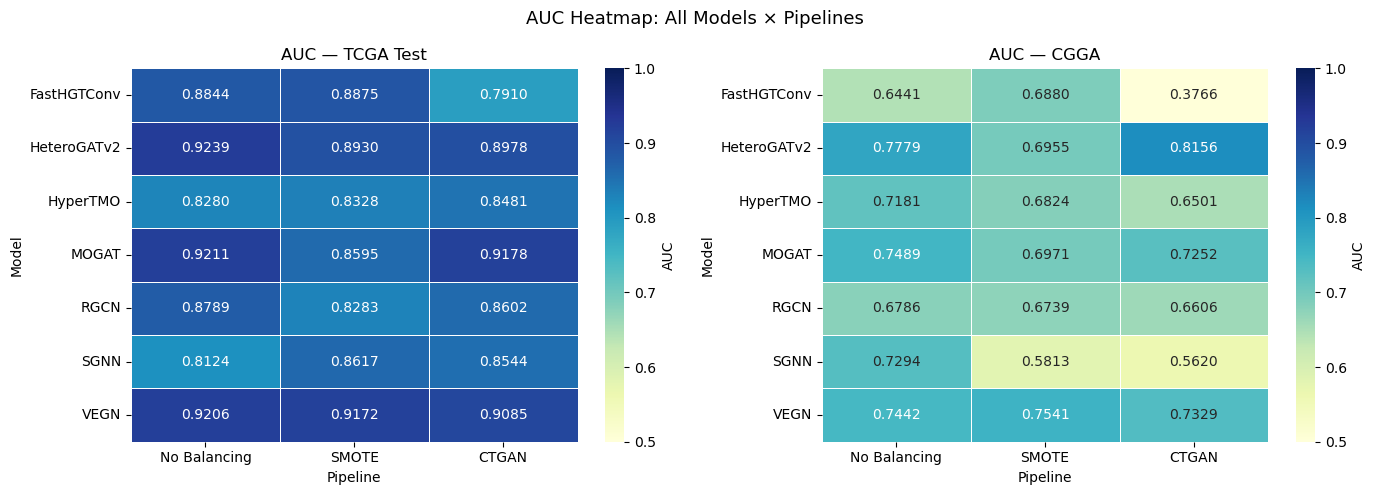

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes, ['TCGA Test', 'CGGA']):
    # pivot_table with aggfunc='mean' safely handles any duplicate rows
    pivot = (results_df[results_df.Dataset == ds]
             .pivot_table(index='Model', columns='Pipeline',
                          values='AUC', aggfunc='mean')
             .reindex(columns=['No Balancing', 'SMOTE', 'CTGAN']))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
                linewidths=0.5, ax=ax, vmin=0.5, vmax=1.0,
                cbar_kws={'label': 'AUC'})
    ax.set_title(f'AUC — {ds}', fontsize=12)
    ax.set_xlabel('Pipeline'); ax.set_ylabel('Model')
plt.suptitle('AUC Heatmap: All Models × Pipelines', fontsize=13)
plt.tight_layout()
plt.savefig('V9_auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 19. Recall Heatmaps — Grade-1 and Grade-0 (TCGA Test)

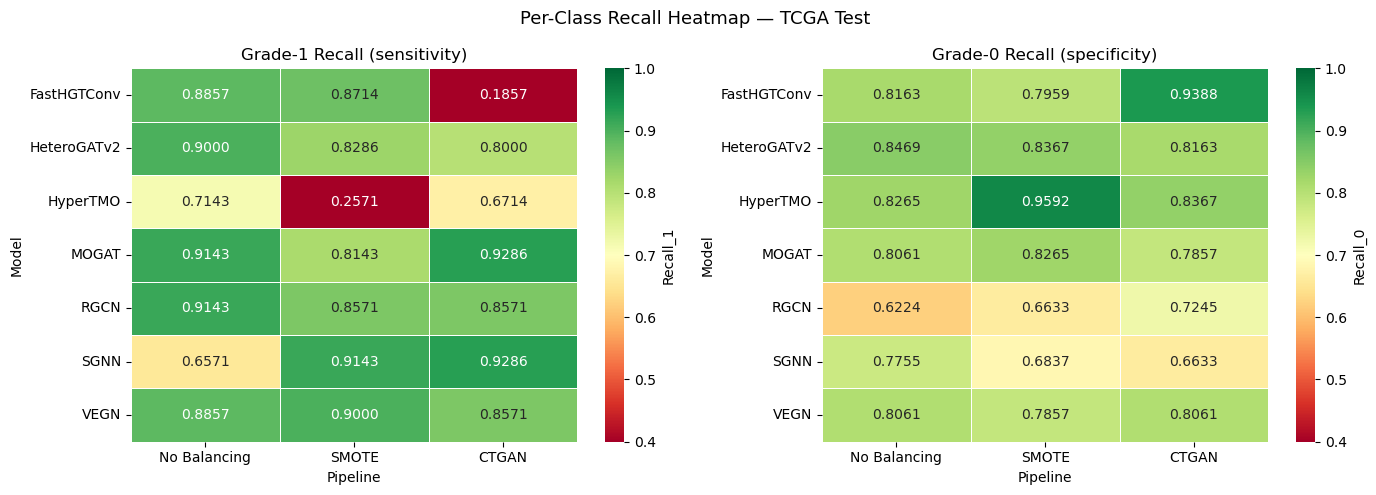

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in [
        (axes[0], 'Recall_1', 'Grade-1 Recall (sensitivity)'),
        (axes[1], 'Recall_0', 'Grade-0 Recall (specificity)')]:
    pivot = (results_df[results_df.Dataset == 'TCGA Test']
             .pivot_table(index='Model', columns='Pipeline',
                          values=col, aggfunc='mean')
             .reindex(columns=['No Balancing', 'SMOTE', 'CTGAN']))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn',
                linewidths=0.5, ax=ax, vmin=0.4, vmax=1.0,
                cbar_kws={'label': col})
    ax.set_title(title); ax.set_xlabel('Pipeline'); ax.set_ylabel('Model')
plt.suptitle('Per-Class Recall Heatmap — TCGA Test', fontsize=13)
plt.tight_layout()
plt.savefig('V9_recall_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 20. 5-Fold CV Box Plots

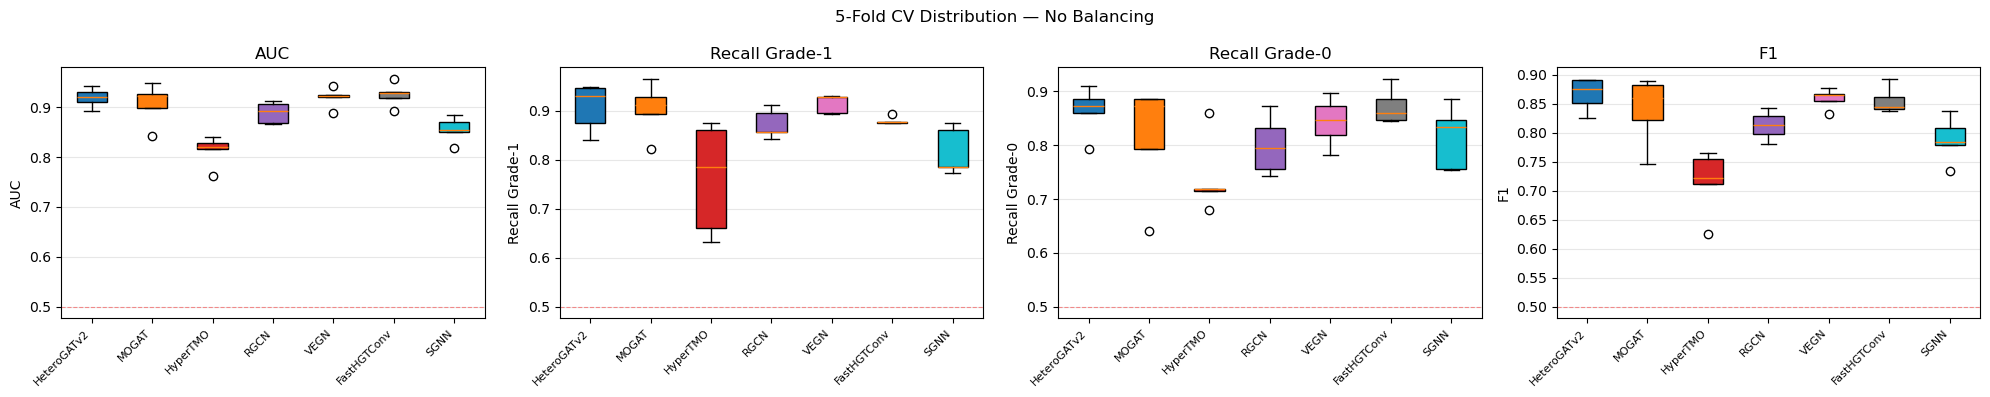

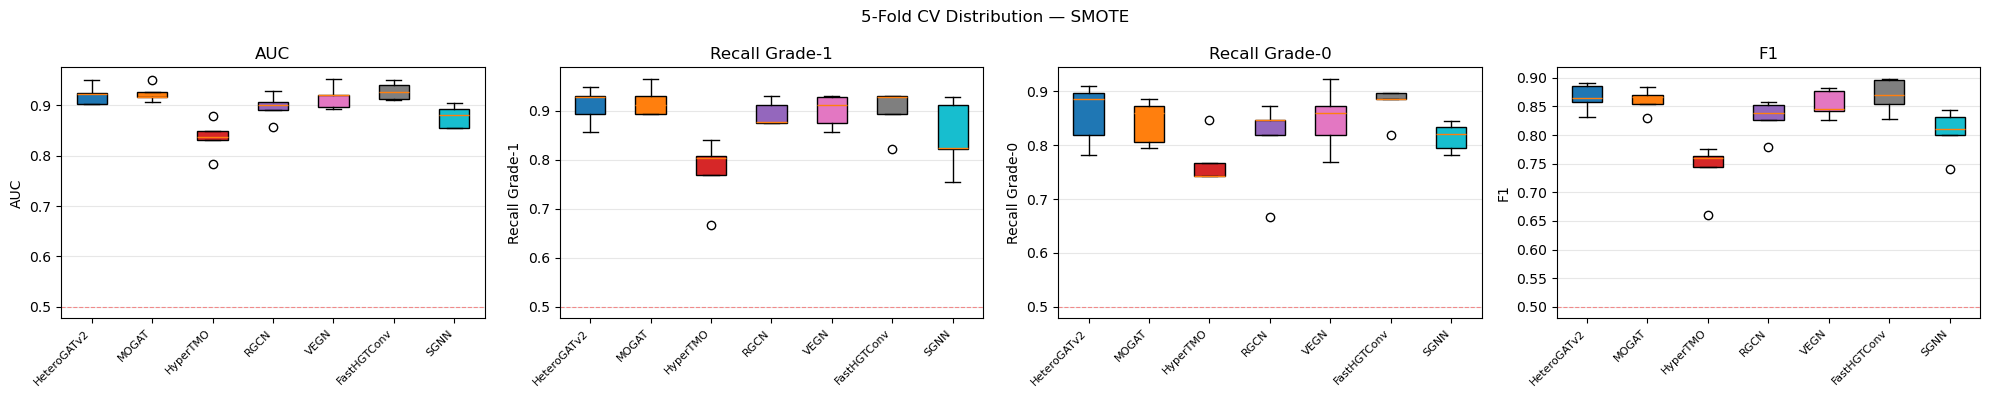

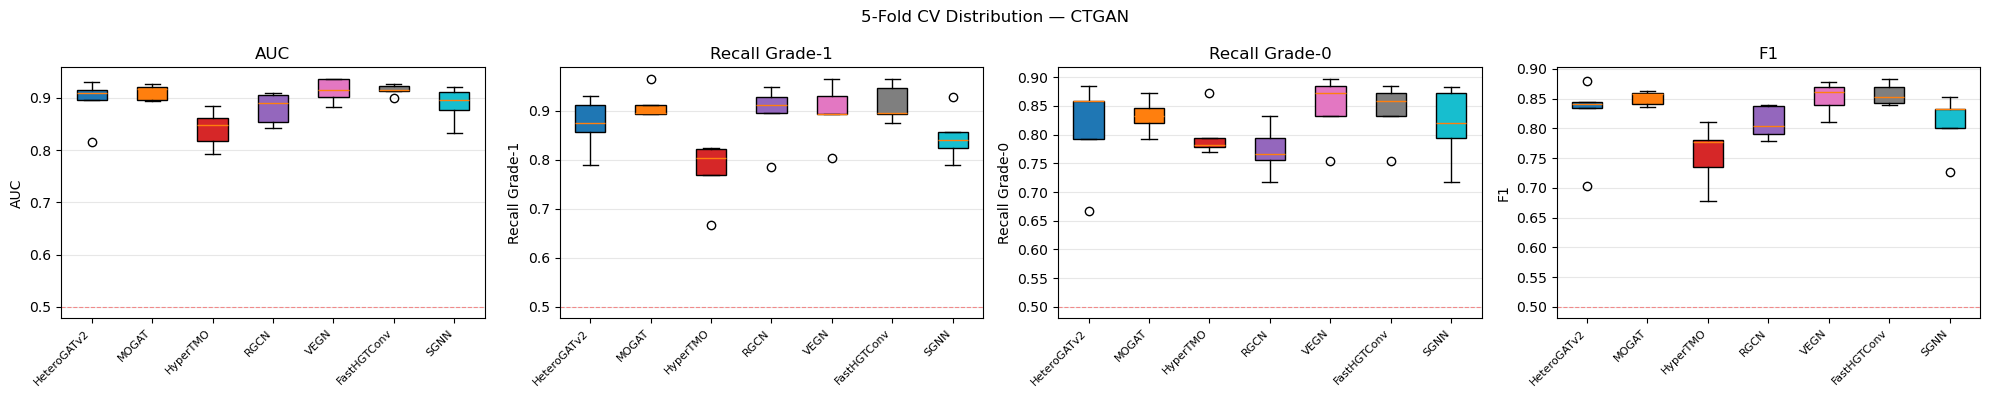

In [22]:
metrics_cv = ['auc', 'recall', 'recall_0', 'f1']
labels_cv  = ['AUC', 'Recall Grade-1', 'Recall Grade-0', 'F1']
model_names = [n for n, _, _ in MODEL_REGISTRY]

for pipe in PIPELINES:
    sub = cv_all[cv_all.Pipeline == pipe]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, met, lab in zip(axes, metrics_cv, labels_cv):
        data = [sub[sub.Model == m][met].values for m in model_names]
        bp = ax.boxplot(data, patch_artist=True, notch=False)
        colors = plt.cm.tab10(np.linspace(0, 0.9, len(model_names)))
        for patch, col in zip(bp['boxes'], colors):
            patch.set_facecolor(col)
        ax.set_xticks(range(1, len(model_names)+1))
        ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel(lab); ax.set_title(lab); ax.grid(axis='y', alpha=0.3)
        ax.axhline(0.5, color='red', ls='--', alpha=0.4, lw=0.8)
    plt.suptitle(f'5-Fold CV Distribution — {pipe}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'V9_cv_boxplot_{pipe.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 21. ROC Curve Grid

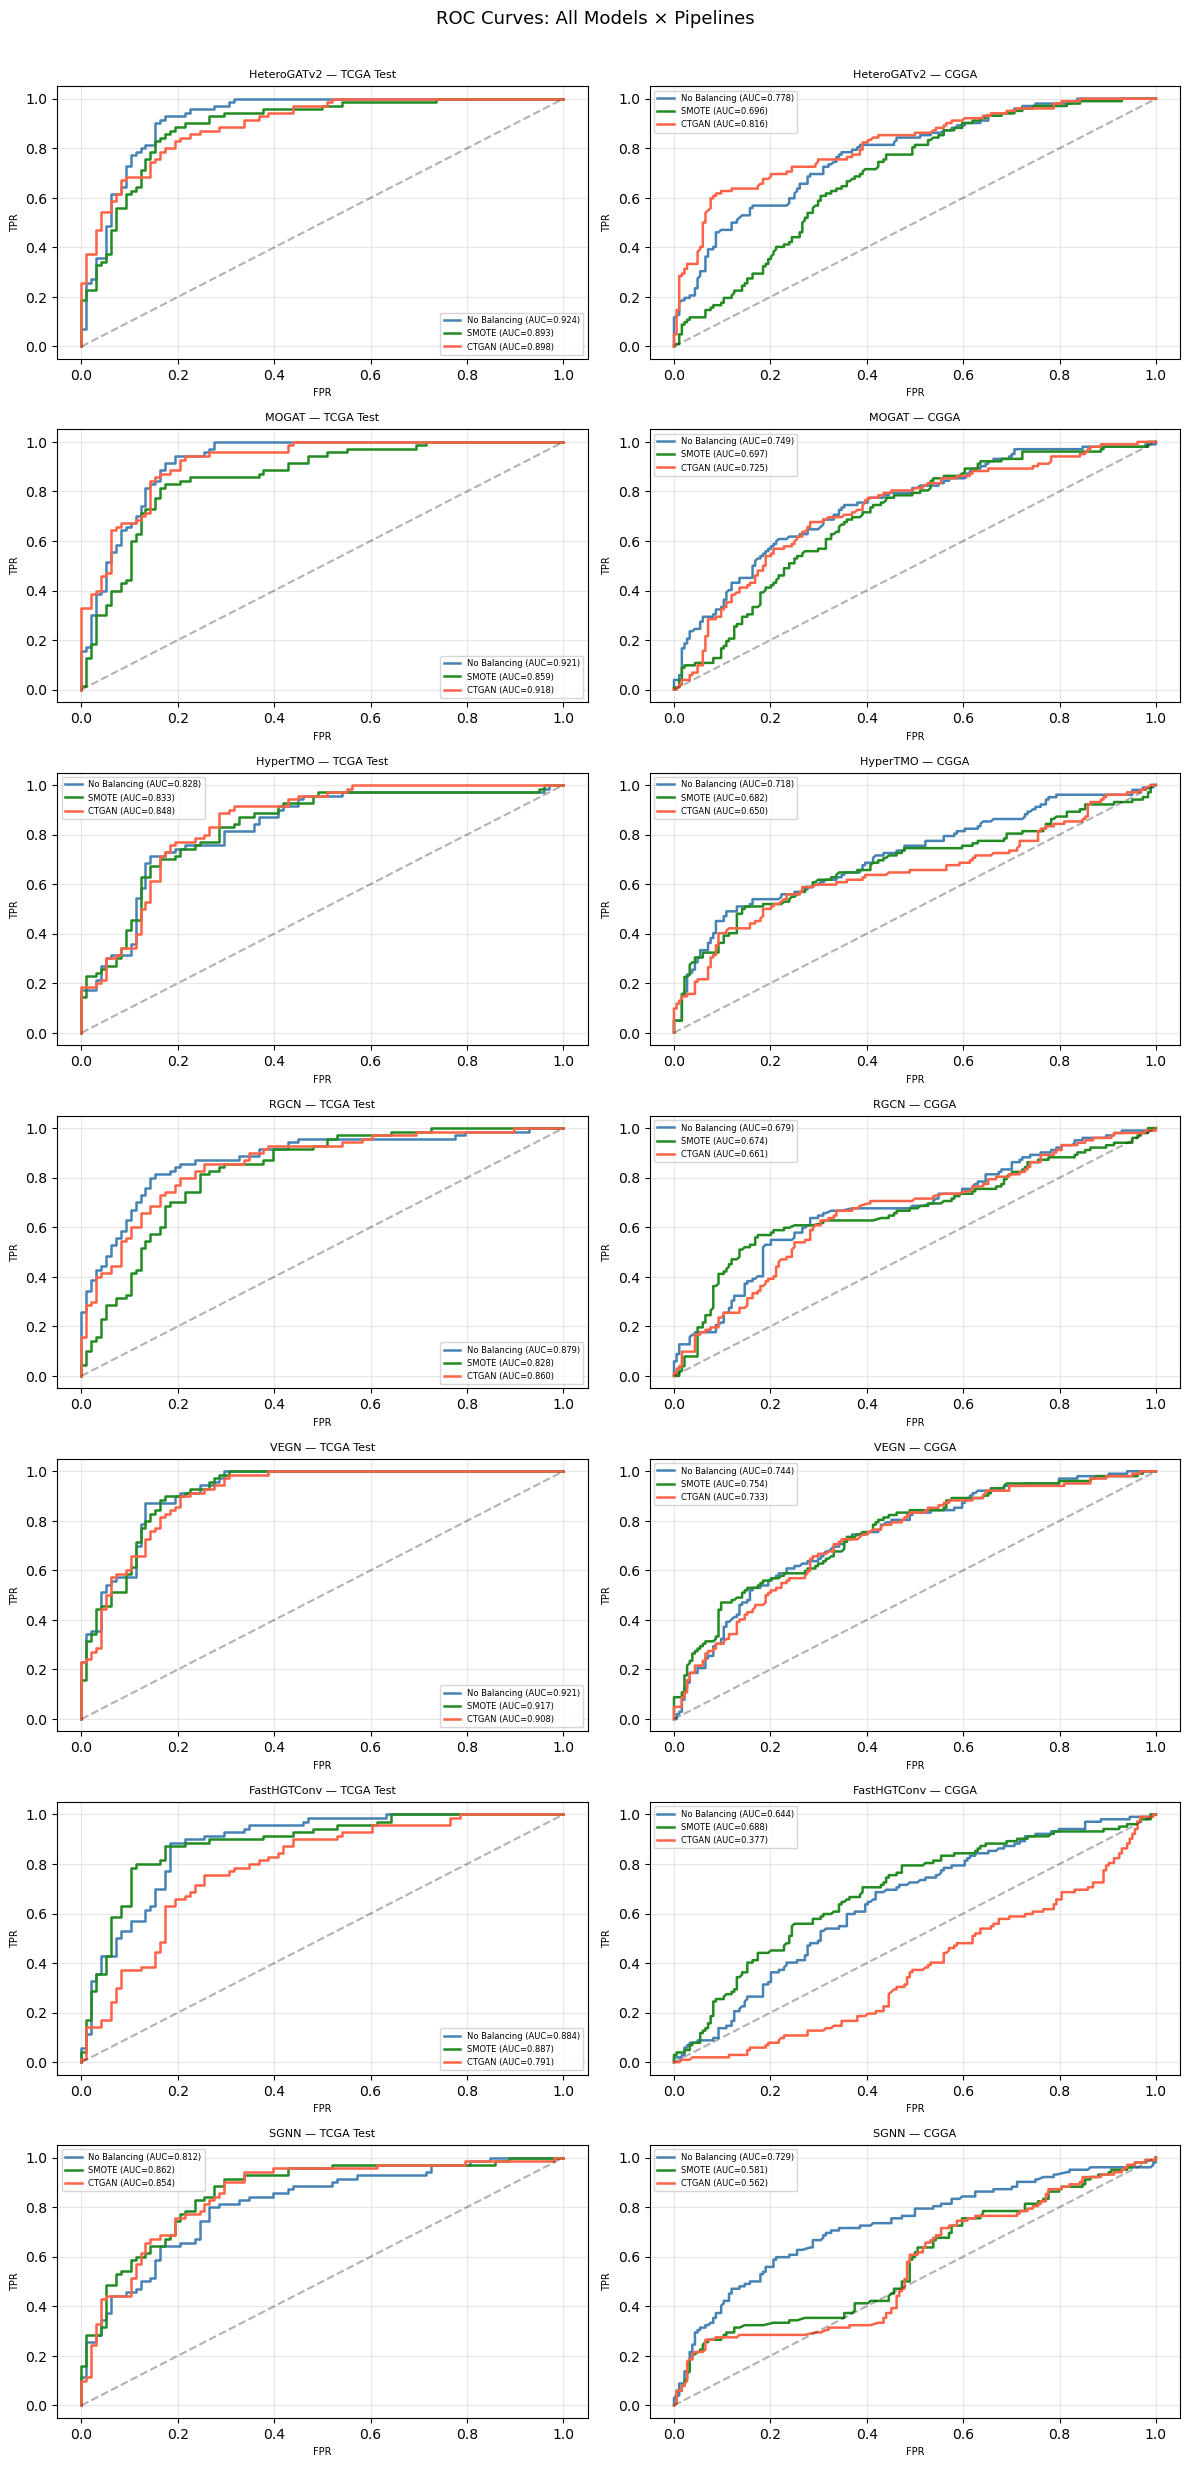

In [23]:
results_full = pd.DataFrame(all_results)
pipe_colors  = {'No Balancing':'steelblue', 'SMOTE':'forestgreen', 'CTGAN':'tomato'}

fig, axes = plt.subplots(len(model_names), 2, figsize=(12, 3.5*len(model_names)))
for row, mname in enumerate(model_names):
    for col, ds in enumerate(['TCGA Test', 'CGGA']):
        ax = axes[row, col]
        for pipe in PIPELINES:
            sub = results_full[(results_full.Model==mname) &
                                (results_full.Pipeline==pipe) &
                                (results_full.Dataset==ds)]
            if sub.empty: continue
            r = sub.iloc[0]
            fpr, tpr, _ = roc_curve(r['labels'], r['probs'])
            ax.plot(fpr, tpr, color=pipe_colors[pipe], lw=1.8,
                    label=f"{pipe} (AUC={r['auc']:.3f})")
        ax.plot([0,1],[0,1],'k--', alpha=0.3)
        ax.set_title(f"{mname} — {ds}", fontsize=8)
        ax.set_xlabel('FPR', fontsize=7); ax.set_ylabel('TPR', fontsize=7)
        ax.legend(fontsize=6); ax.grid(alpha=0.3)
plt.suptitle('ROC Curves: All Models × Pipelines', fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig('V9_roc_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 22. Confusion Matrices

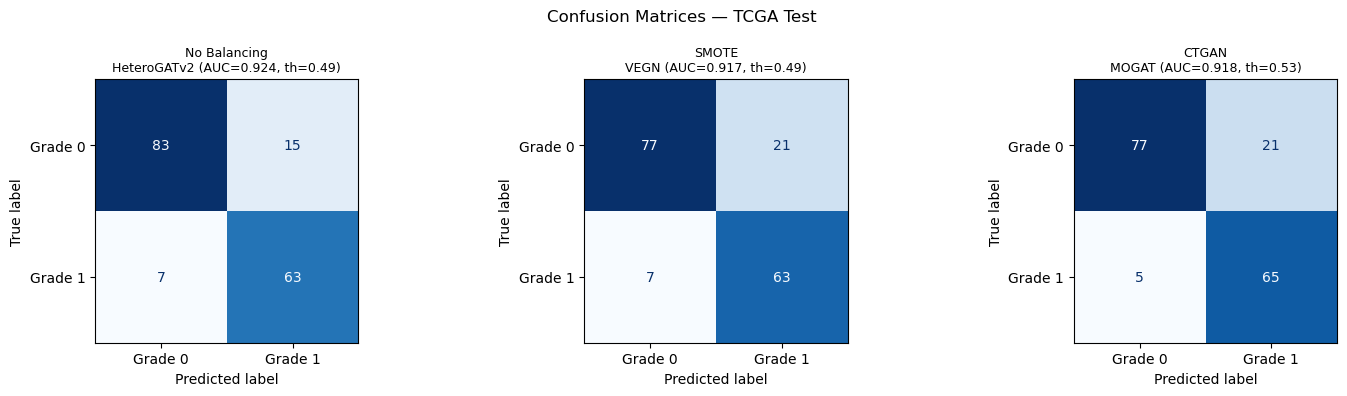

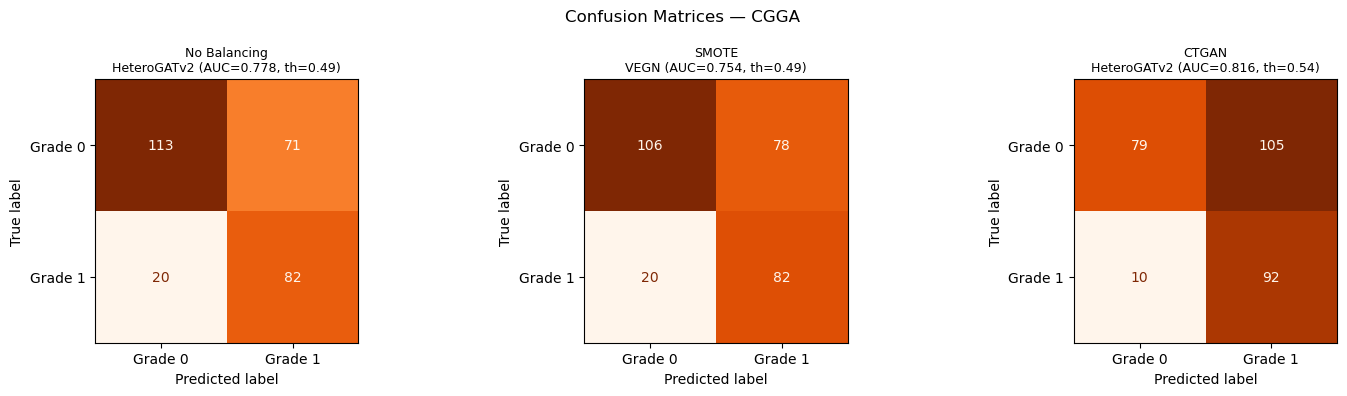

In [24]:
for ds in ['TCGA Test', 'CGGA']:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    cmap = 'Blues' if ds == 'TCGA Test' else 'Oranges'
    for pi, pipe in enumerate(PIPELINES):
        sub  = results_full[(results_full.Dataset==ds) & (results_full.Pipeline==pipe)]
        if sub.empty: continue
        best = sub.loc[sub['auc'].idxmax()]
        th   = best['threshold']
        preds = (best['probs'] >= th).astype(int)
        cm    = confusion_matrix(best['labels'], preds)
        ConfusionMatrixDisplay(cm, display_labels=['Grade 0','Grade 1']).plot(
            ax=axes[pi], cmap=cmap, colorbar=False)
        axes[pi].set_title(f"{pipe}\n{best['Model']} (AUC={best['auc']:.3f}, th={th:.2f})",
                           fontsize=9)
    plt.suptitle(f'Confusion Matrices — {ds}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'V9_cm_{ds.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 23. Permutation Gene Feature Importance

In [25]:
def perm_importance(model, ref_df, threshold=0.5, n_repeats=10, seed=0):
    base_g = to_dev(construct_bipartite_heterograph(ref_df))
    model.eval()
    with torch.no_grad():
        bp = F.softmax(model(base_g), 1)[:, 1].cpu().numpy()
    try:
        base_auc = roc_auc_score(ref_df['Grade'].values, bp)
    except ValueError:
        return {g: 0.0 for g in gene_columns}, 0.0
    rng = np.random.default_rng(seed)
    out = {}
    for gene in gene_columns:
        drops = []
        for _ in range(n_repeats):
            df2 = ref_df.copy(); df2[gene] = rng.permutation(df2[gene].values)
            g2  = to_dev(construct_bipartite_heterograph(df2))
            with torch.no_grad():
                pp = F.softmax(model(g2), 1)[:, 1].cpu().numpy()
            try:
                drops.append(base_auc - roc_auc_score(ref_df['Grade'].values, pp))
            except ValueError:
                drops.append(0.0)
        out[gene] = float(np.mean(drops))
    clear_pp_cache()
    return out, base_auc

print("Computing permutation importance...")
imp_records = []
for mname, MCls, _ in MODEL_REGISTRY:
    for pipe in PIPELINES:
        model = all_models.get((mname, pipe))
        if model is None: continue
        th  = all_thresholds.get((mname, pipe), 0.5)
        imp, base = perm_importance(model, test_df, threshold=th)
        for gene, drop in imp.items():
            imp_records.append({'Model': mname, 'Pipeline': pipe,
                                 'Gene': gene, 'AUC_Drop': drop, 'Base_AUC': base})
        print(f"  {mname}/{pipe}  base={base:.4f}")
imp_df = pd.DataFrame(imp_records)
print("Done.")

Computing permutation importance...
  HeteroGATv2/No Balancing  base=0.9239
  HeteroGATv2/SMOTE  base=0.8930
  HeteroGATv2/CTGAN  base=0.8978
  MOGAT/No Balancing  base=0.9211
  MOGAT/SMOTE  base=0.8595
  MOGAT/CTGAN  base=0.9178
  HyperTMO/No Balancing  base=0.8280
  HyperTMO/SMOTE  base=0.8328
  HyperTMO/CTGAN  base=0.8481
  RGCN/No Balancing  base=0.8789
  RGCN/SMOTE  base=0.8283
  RGCN/CTGAN  base=0.8602
  VEGN/No Balancing  base=0.9206
  VEGN/SMOTE  base=0.9172
  VEGN/CTGAN  base=0.9085
  FastHGTConv/No Balancing  base=0.8844
  FastHGTConv/SMOTE  base=0.8875
  FastHGTConv/CTGAN  base=0.7910
  SGNN/No Balancing  base=0.8124
  SGNN/SMOTE  base=0.8617
  SGNN/CTGAN  base=0.8544
Done.


## 24. Feature Importance Plots

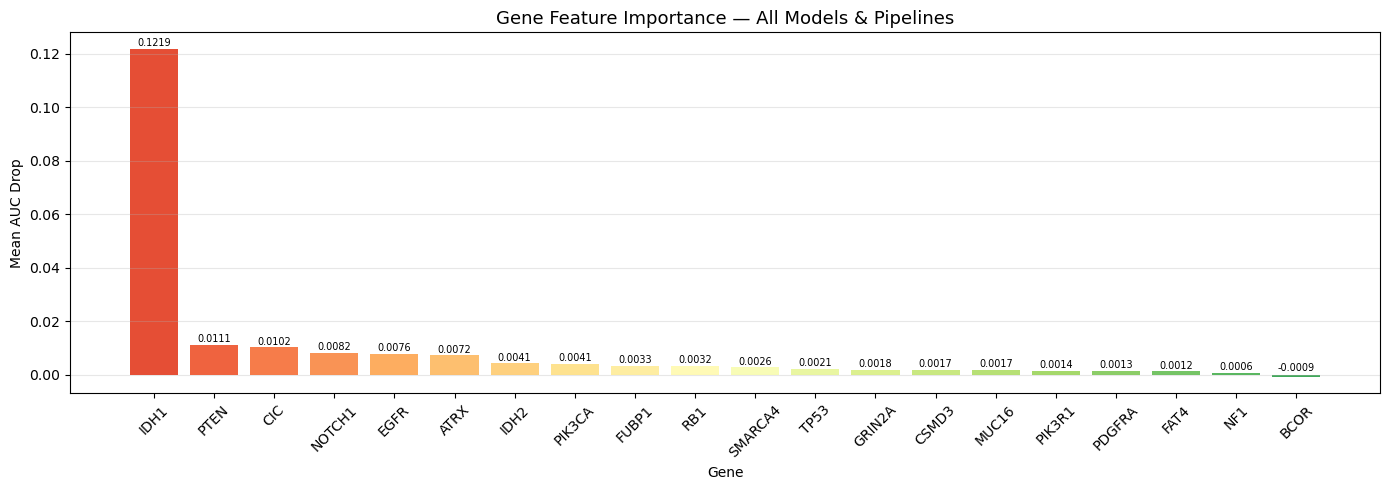

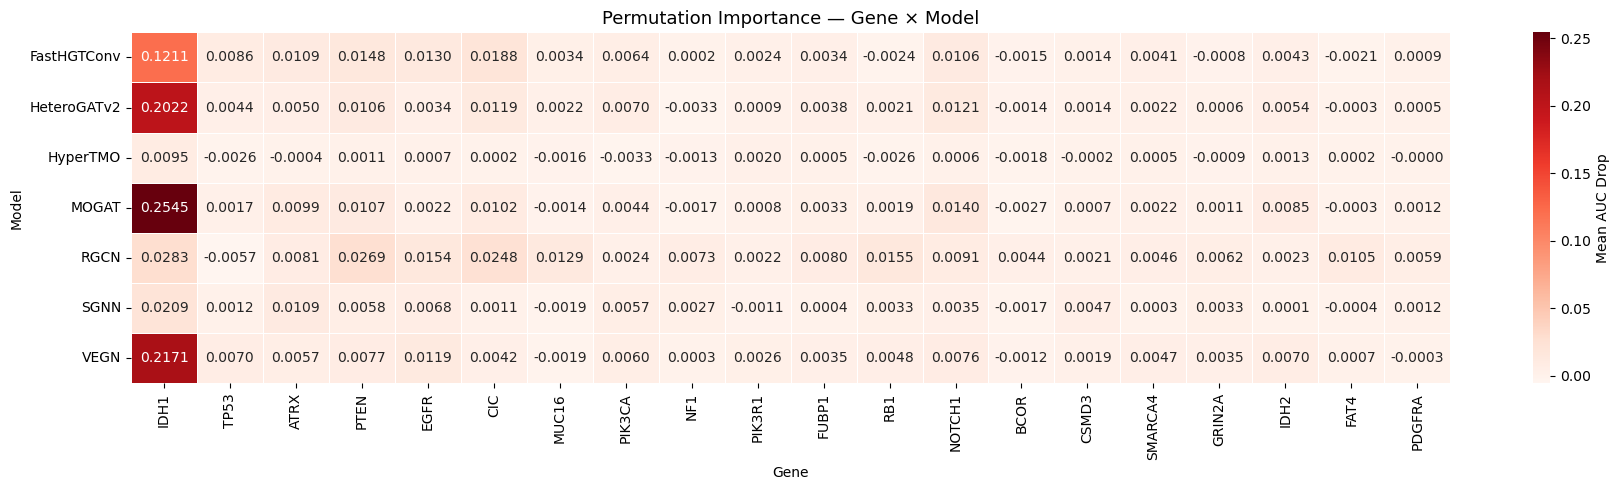


Top-5 most important genes:
Gene
IDH1      0.121938
PTEN      0.011109
CIC       0.010178
NOTCH1    0.008233
EGFR      0.007626


In [26]:
mean_imp = (imp_df.groupby('Gene')['AUC_Drop']
            .mean().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(14, 5))
cvals = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(mean_imp)))
bars  = ax.bar(mean_imp.index, mean_imp.values, color=cvals)
ax.set_xlabel('Gene'); ax.set_ylabel('Mean AUC Drop')
ax.set_title('Gene Feature Importance — All Models & Pipelines', fontsize=13)
ax.tick_params(axis='x', rotation=45); ax.grid(axis='y', alpha=0.3)
for b, v in zip(bars, mean_imp.values):
    ax.text(b.get_x()+b.get_width()/2, max(v+0.0003, 0.0005),
            f'{v:.4f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig('V8_feat_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Heatmap: Gene × Model
heat = (imp_df.groupby(['Model','Gene'])['AUC_Drop']
        .mean().unstack('Gene')[gene_columns])
fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(heat, annot=True, fmt='.4f', cmap='Reds', linewidths=0.4,
            ax=ax, cbar_kws={'label': 'Mean AUC Drop'})
ax.set_title('Permutation Importance — Gene × Model', fontsize=13)
plt.tight_layout()
plt.savefig('V9_feat_importance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop-5 most important genes:")
print(mean_imp.head(5).to_string())

## 25. GAT Attention Weights

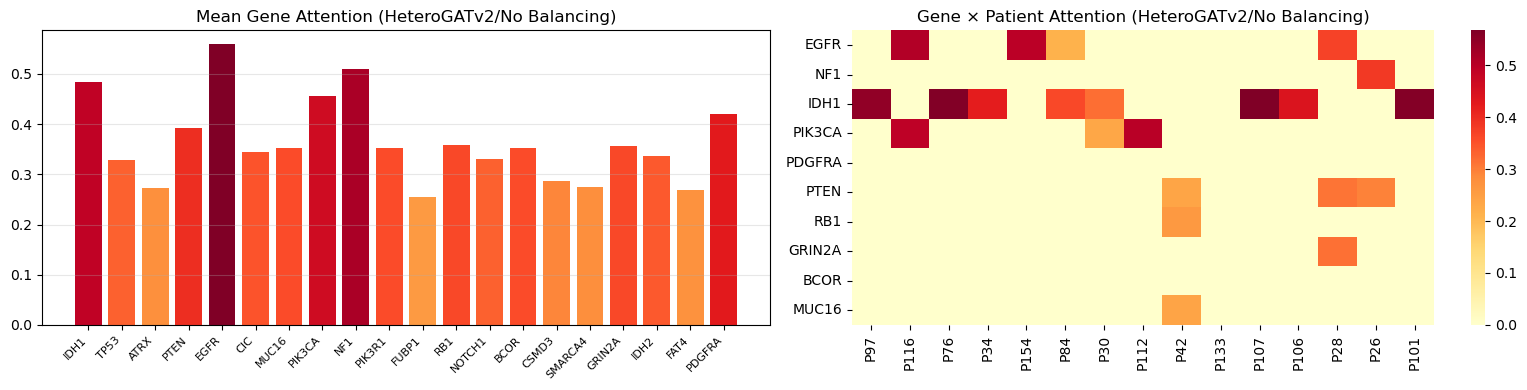

  MOGAT has no get_attn_weights — skipping.


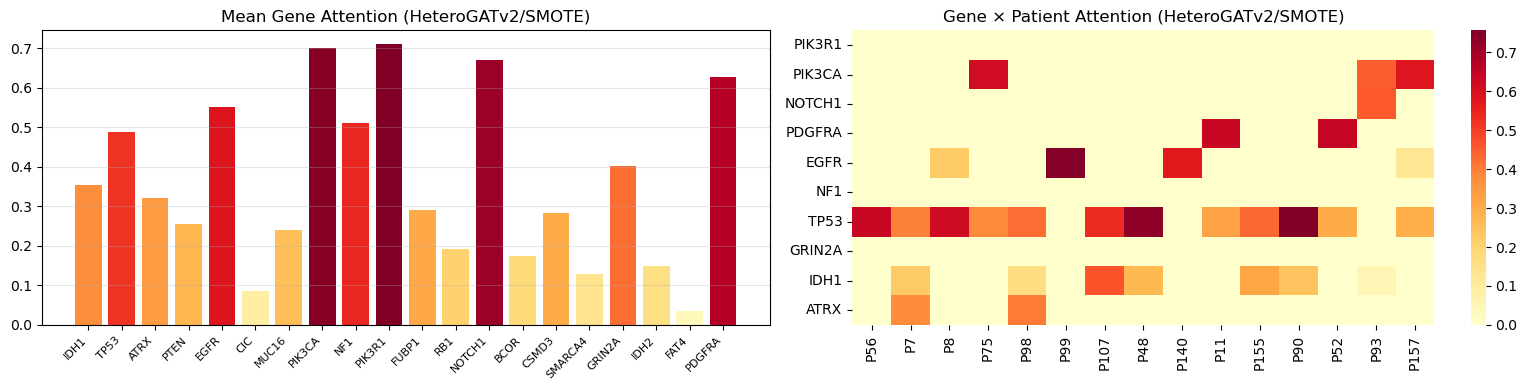

  MOGAT has no get_attn_weights — skipping.


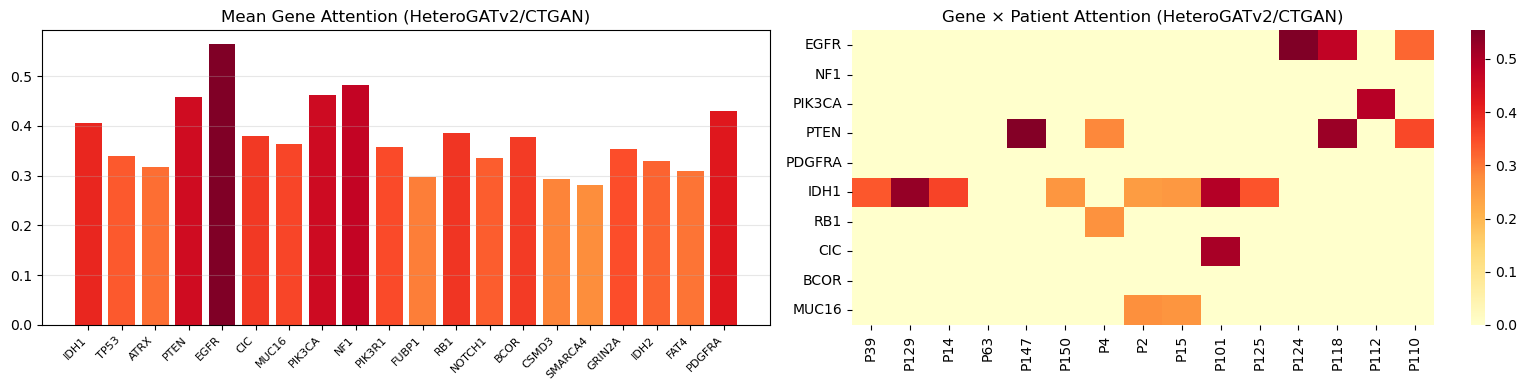

  MOGAT has no get_attn_weights — skipping.


In [27]:
def plot_gene_attention(model, graph, ref_df, title):
    model.eval()
    if not hasattr(model, 'get_attn_weights'):
        print(f"  {type(model).__name__} has no get_attn_weights — skipping."); return
    try:
        eidx, weights = model.get_attn_weights(graph)
    except Exception as e:
        print(f"  Attention extraction failed: {e}"); return
    gene_ids = eidx[0].cpu().numpy(); w = weights.cpu().numpy()
    gene_attn = np.zeros(NUM_GENES); gene_cnt = np.zeros(NUM_GENES)
    for g, wt in zip(gene_ids, w):
        if 0 <= g < NUM_GENES: gene_attn[g] += wt; gene_cnt[g] += 1
    gene_cnt = np.maximum(gene_cnt, 1); gene_attn /= gene_cnt
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    norm_a = gene_attn / (gene_attn.max() + 1e-9)
    axes[0].bar(gene_columns, gene_attn, color=plt.cm.YlOrRd(norm_a))
    axes[0].set_xticklabels(gene_columns, rotation=45, ha='right', fontsize=8)
    axes[0].set_title(f'Mean Gene Attention ({title})'); axes[0].grid(axis='y', alpha=0.3)
    pat_ids = eidx[1].cpu().numpy(); n_pat = ref_df.shape[0]
    top_g = np.argsort(gene_attn)[::-1][:10]
    pat_wsum = np.zeros(n_pat)
    for g, p, wt in zip(gene_ids, pat_ids, w):
        if 0 <= p < n_pat: pat_wsum[p] += wt
    top_p = np.argsort(pat_wsum)[::-1][:15]
    mat = np.zeros((len(top_g), len(top_p)))
    for g_loc, g in enumerate(top_g):
        for p_loc, p in enumerate(top_p):
            mask = (gene_ids == g) & (pat_ids == p)
            if mask.any(): mat[g_loc, p_loc] = w[mask].mean()
    sns.heatmap(mat, ax=axes[1], cmap='YlOrRd',
                xticklabels=[f'P{p}' for p in top_p],
                yticklabels=[gene_columns[g] for g in top_g])
    axes[1].set_title(f'Gene × Patient Attention ({title})')
    plt.tight_layout()
    plt.savefig(f'V8_attn_{title.replace("/","_").replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

for pipe in PIPELINES:
    for mname in ['HeteroGATv2', 'MOGAT']:
        m = all_models.get((mname, pipe))
        if m: plot_gene_attention(m, test_graph, test_df, f"{mname}/{pipe}")

## 26. Classification Reports — Best Model Overall

In [28]:
for ds in ['TCGA Test','CGGA']:
    sub  = results_full[results_full.Dataset==ds]
    best = sub.loc[sub['auc'].idxmax()]
    th   = best['threshold']
    preds  = (best['probs'] >= th).astype(int)
    labels = best['labels']
    print(f"{'='*65}")
    print(f"Best on {ds}: {best['Model']} / {best['Pipeline']}")
    print(f"AUC={best['auc']:.4f}  Threshold={th:.3f}")
    print(classification_report(labels, preds, target_names=['Grade 0','Grade 1']))

Best on TCGA Test: HeteroGATv2 / No Balancing
AUC=0.9239  Threshold=0.490
              precision    recall  f1-score   support

     Grade 0       0.92      0.85      0.88        98
     Grade 1       0.81      0.90      0.85        70

    accuracy                           0.87       168
   macro avg       0.86      0.87      0.87       168
weighted avg       0.87      0.87      0.87       168

Best on CGGA: HeteroGATv2 / CTGAN
AUC=0.8156  Threshold=0.540
              precision    recall  f1-score   support

     Grade 0       0.89      0.43      0.58       184
     Grade 1       0.47      0.90      0.62       102

    accuracy                           0.60       286
   macro avg       0.68      0.67      0.60       286
weighted avg       0.74      0.60      0.59       286



## 27. Save Results

In [29]:
# import os
# os.makedirs('saved_models_v8', exist_ok=True)
# for (mname, pipe), model in all_models.items():
#     fn = f"saved_models_v8/{mname}_{pipe.replace(' ','_')}.pth"
#     torch.save(model.state_dict(), fn)

# pd.DataFrame([{'Model': mn, 'Pipeline': pp, 'Threshold': th}
#                for (mn, pp), th in all_thresholds.items()]).to_csv('V8_thresholds.csv', index=False)
# if 'imp_df' in dir() and not imp_df.empty:
#     imp_df.to_csv('V8_feature_importance.csv', index=False)
#     print("✓ Exported: V8_feature_importance.csv")

# print("✓ Saved model weights to saved_models_v8/")
# print("\nFinal AUC Pivot:")
# print(results_df.pivot_table(index='Model', columns=['Pipeline','Dataset'],
#                               values='AUC', aggfunc='mean').round(4).to_string())